#### Project - `Analyzing Naming Trends Using Python`

#### Problem Statement : 

This project analyzes historical baby name data to identify trends in naming patterns across different years. The goal is to explore gender-based birth distributions, determine the most popular baby names, and visualize trends using Python-based data analysis tools.

`BytesIO` is very useful when data is not coming from a file on disk, but instead from memory, such as:
- API responses
- ZIP files
- Cloud storage
- Uploaded files
- Streaming data

#### 1. Import necessary libraries

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import zipfile
from io import BytesIO

#### 2. Extract only useful files from Zip using zipfile + BytesIO

In [5]:
# Zip path

zip_path = 'D:\\INTELLIPAAT LEARNINGS COM FILES\\PYTHON\\VS Code Python\\dsenv\\names.zip'

# create empty list named `data_frames` to store data in it.
data_frames = []

with zipfile.ZipFile(zip_path, 'r') as z:
    
    # List all files inside zip
    all_files = z.namelist()
    
    # Filter useful files (baby name data files)
    useful_files = [f for f in all_files if f.startswith('yob') and f.endswith('.txt')]
    
    for file_name in useful_files:
        df = pd.read_csv(
            BytesIO(z.read(file_name)),
            engine='python',
            header=None,
            encoding='utf-8'
        )
        
        df.columns = ['Name', 'Gender', 'Count']
        
        # Extract year from filename (e.g., yob2010.txt → 2010)
        year = int(file_name[3:7])
        df['Year'] = year
        
        data_frames.append(df)

In [6]:
# Combine All years into One dataframe
baby_df = pd.concat(data_frames, ignore_index = True)
baby_df.head()

,Name,Gender,Count,Year
0,Mary,F,7065,1880
1,Anna,F,2604,1880
2,Emma,F,2003,1880
3,Elizabeth,F,1939,1880
4,Minnie,F,1746,1880


In [9]:
# How many years of data we have
baby_df['Year'].value_counts()

Year
2008    35102
2007    34976
2009    34735
2006    34107
2010    34105
        ...  
1885     2294
1882     2127
1883     2084
1880     2000
1881     1934
Name: count, Length: 145, dtype: int64

#### 3. Visualize the Number of Male and Female babies borin in particular year 

In [10]:
# Extracting records where year is 2010
year = 2010

year_2010_data = baby_df[baby_df['Year'] == year]
year_2010_data

,Name,Gender,Count,Year
1658527,Isabella,F,22935,2010
1658528,Sophia,F,20655,2010
1658529,Emma,F,17364,2010
1658530,Olivia,F,17037,2010
1658531,Ava,F,15442,2010
...,...,...,...,...
1692627,Zymaire,M,5,2010
1692628,Zyonne,M,5,2010
1692629,Zyquarius,M,5,2010
1692630,Zyran,M,5,2010


In [11]:
# aggregate birth counts by gender
birth_counts_by_gender = year_2010_data.groupby('Gender')['Count'].sum()
birth_counts_by_gender

Gender
F    1777327
M    1918412
Name: Count, dtype: int64

<Axes: title={'center': 'Male vs Female Babies Birth Counts in 2010'}, xlabel='Gender', ylabel='Number of Births'>

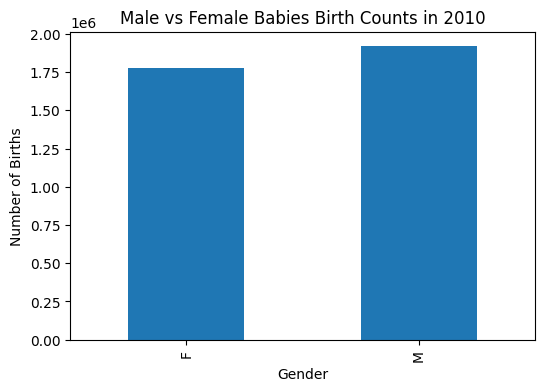

In [12]:
# plot the birth counts using plot
birth_counts_by_gender.plot(
    kind = 'bar',
    title = f'Male vs Female Babies Birth Counts in {year}',
    xlabel = 'Gender',
    ylabel = 'Number of Births',
    figsize = (6,4)
)

**Insights:**
The number of male babies born are more than the number of female babies born in the year 2010.

#### 4. Analyze baby names by sorting out all birth counts

In [13]:
# Sort names by total births (across all years)
name_totals = baby_df.groupby('Name')['Count'].sum()

# sort the names in descending order
sorted_name_totals = name_totals.sort_values(ascending = False)

In [14]:
sorted_name_totals

Name
James        5262396
John         5196210
Robert       4866007
Michael      4440391
William      4205026
              ...   
Low                5
Zytaevius          5
Zytavion           5
Zyvion             5
Acelee             5
Name: Count, Length: 104819, dtype: int64

**Insights:**

- Reveals most common names historically.
- Names like `James`, `John`, `Robert` usually dominate other names.

#### 5. Top 100 Birth Counts & Group by Names (Popular Names)

In [15]:
# Filter Top 100 Records by Count
top_100 = baby_df.sort_values('Count', ascending = False).head(100)
top_100

,Name,Gender,Count,Year
431068,Linda,F,99693,1947
441439,Linda,F,96216,1948
437172,James,M,94763,1947
544684,Michael,M,92786,1957
437173,Robert,M,91654,1947
...,...,...,...,...
478470,Michael,M,72805,1951
604246,James,M,72561,1962
579878,Robert,M,72344,1960
191061,Mary,F,72176,1922


In [16]:
# Group by Name to Find Most Popular Names
popular_baby_names = (
    top_100.groupby('Name')['Count'].sum().sort_values(ascending = False)
)

In [17]:
# Top 10 popular baby names
popular_baby_names.head(10)

Name
James      1808655
Michael    1768254
John       1525130
Robert     1467572
David       978214
Linda       441338
Mary        219694
Name: Count, dtype: int64

#### 6. Visualize Top 10 Popular Names

<Axes: title={'center': 'Top 10 Popular Baby Names'}, xlabel='Name'>

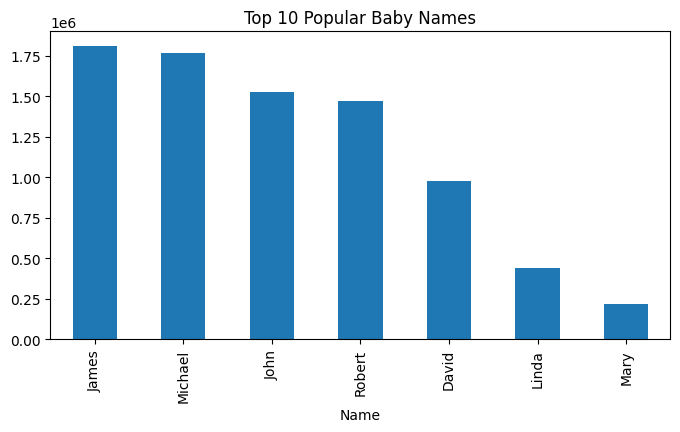

In [18]:
popular_baby_names.head(10).plot(
    kind = 'bar',
    title = 'Top 10 Popular Baby Names',
    figsize = (8,4)
)

**Insights:**
* The Top 10 most popular baby names are : James, Michael, John, Robert, David, Linda, Mary etc.

#### Exploratory Data Analysis (EDA) :

Several analytical steps were performed to understand the dataset:

- Analyzed the number of male and female births per year

- Aggregated birth counts based on gender

- Sorted birth counts in descending order to identify popular baby names

- Extracted the top 100 most popular names

- Identified the top 10 names based on birth frequency

Visualizations were created using bar plots to better understand patterns and comparisons.

**Key Insights :**

The analysis revealed several interesting findings:

- Male and female birth counts show clear distribution patterns across years.

- Certain names consistently appear among the most popular choices.

- In the year 2010, popular names included:

	- James

	- Michael

	- John

	- Robert

	- David

	- Linda

	- Mary

These results demonstrate recurring naming preferences and cultural trends reflected in the data.
